In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import zscore
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False

In [2]:
zscore_df = pd.read_csv('../../data/busan_youth_zscore_only.csv')
zscore_df.head(5)

,연도,행정구역,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
0,2016,강원특별자치도,-0.119064,-0.284835,-0.600234,-0.205085,0.854703,1.549660,-0.387657,-0.455941,-1.188626,-0.520361
1,2016,경기도,0.014971,-0.045046,0.166934,0.680446,-0.923381,-0.598474,3.040583,2.946692,1.069933,2.677738
2,2016,경상남도,-0.359782,-0.291791,-0.012171,-0.117638,-0.652955,-0.214410,0.162636,0.105927,-0.370107,0.045773
3,2016,경상북도,-0.370028,-0.304519,0.161814,-0.351067,1.482685,0.118136,-0.025902,-0.100210,-0.975500,0.035230
4,2016,광주광역시,-0.426919,-0.547518,-0.674692,-0.262193,0.839705,-0.627009,-0.500104,-0.479118,0.209941,-0.563549


In [3]:
zscore_df.columns

Index(['연도', '행정구역', '청년_19_29_증감률(%)_z', '청년_30_39_증감률(%)_z', '상용월평균급여(원)_z',
       '문화예술활동(건)_z', '대학수(천명당)_z', '문화기반시설수(십만명당)_z', '기업밀도_z', '연앙인구수(천명)_z',
       '재정자립도(%)_z', '지역내총생산(십억원)_z'],
      dtype='object')

---

## 전국 행정구역 청년 증감률 Z-score 추세

전국 행정구역 청년(19~29) 증감률 Z-score 추세

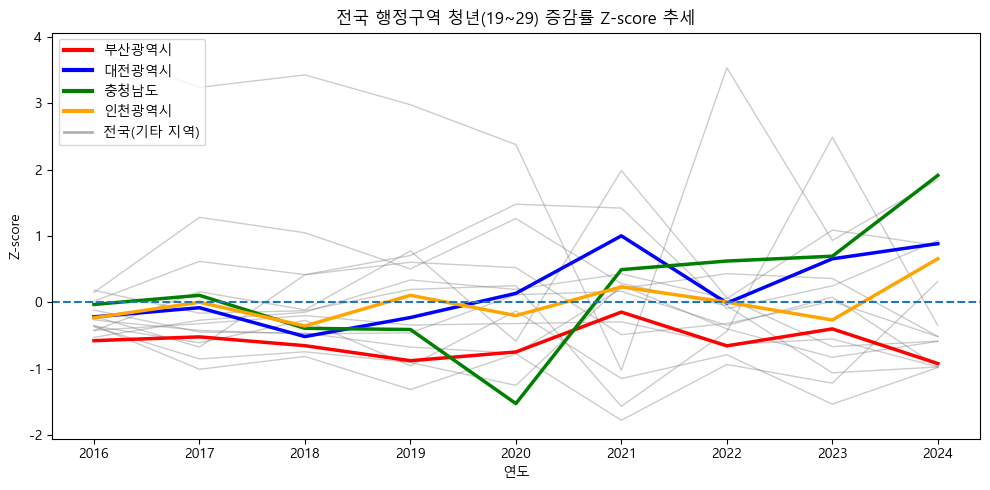

In [4]:
highlight_regions = ['부산광역시', '대전광역시', '충청남도', '인천광역시']
target_col = '청년_19_29_증감률(%)_z'

plt.figure(figsize=(10, 5))

# 1) 전국 전체 (기타 지역 포함)
for region in zscore_df['행정구역'].unique():
    tmp = zscore_df[zscore_df['행정구역'] == region]
    plt.plot(
        tmp['연도'],
        tmp[target_col],
        color='gray',
        alpha=0.4,
        linewidth=1
    )

# 2) 강조 지역 덮어쓰기
colors = {
    '부산광역시': 'red',
    '대전광역시': 'blue',
    '충청남도': 'green',
    '인천광역시': 'orange'
}

for region in highlight_regions:
    tmp = zscore_df[zscore_df['행정구역'] == region]
    plt.plot(
        tmp['연도'],
        tmp[target_col],
        color=colors[region],
        linewidth=2.5
    )

plt.axhline(0, linestyle='--')
plt.title('전국 행정구역 청년(19~29) 증감률 Z-score 추세')
plt.xlabel('연도')
plt.ylabel('Z-score')

# 3) legend 수동 구성 (핵심)
legend_elements = [
    Line2D([0], [0], color='red', lw=3, label='부산광역시'),
    Line2D([0], [0], color='blue', lw=3, label='대전광역시'),
    Line2D([0], [0], color='green', lw=3, label='충청남도'),
    Line2D([0], [0], color='orange', lw=3, label='인천광역시'),
    Line2D([0], [0], color='gray', lw=2, alpha=0.6, label='전국(기타 지역)')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()


전국 행정구역 청년(30~39) 증감률 Z-score 추세

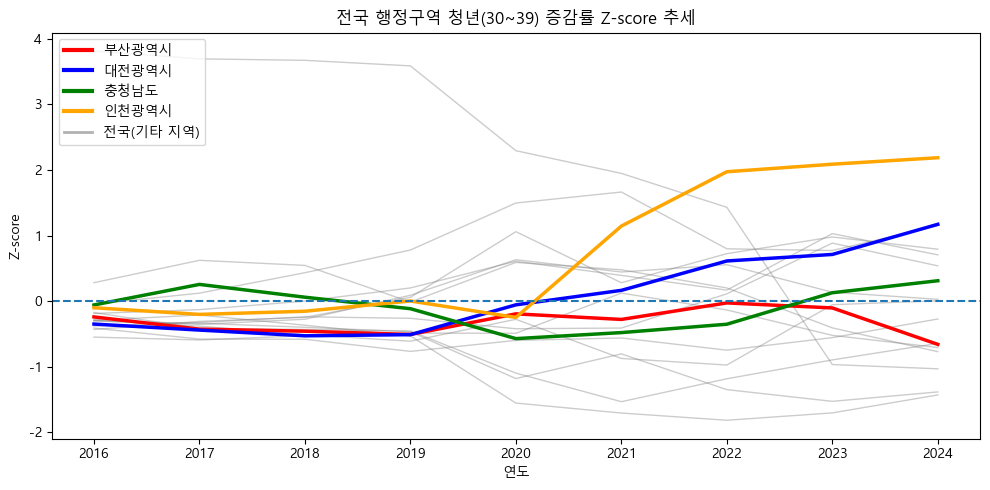

In [5]:
highlight_regions = ['부산광역시', '대전광역시', '충청남도', '인천광역시']
target_col = '청년_30_39_증감률(%)_z'

plt.figure(figsize=(10, 5))

# 1) 전국 전체 (기타 지역 포함)
for region in zscore_df['행정구역'].unique():
    tmp = zscore_df[zscore_df['행정구역'] == region]
    plt.plot(
        tmp['연도'],
        tmp[target_col],
        color='gray',
        alpha=0.4,
        linewidth=1
    )

# 2) 강조 지역 덮어쓰기
colors = {
    '부산광역시': 'red',
    '대전광역시': 'blue',
    '충청남도': 'green',
    '인천광역시': 'orange'
}

for region in highlight_regions:
    tmp = zscore_df[zscore_df['행정구역'] == region]
    plt.plot(
        tmp['연도'],
        tmp[target_col],
        color=colors[region],
        linewidth=2.5
    )

plt.axhline(0, linestyle='--')
plt.title('전국 행정구역 청년(30~39) 증감률 Z-score 추세')
plt.xlabel('연도')
plt.ylabel('Z-score')

# 3) legend 수동 구성 (핵심)
legend_elements = [
    Line2D([0], [0], color='red', lw=3, label='부산광역시'),
    Line2D([0], [0], color='blue', lw=3, label='대전광역시'),
    Line2D([0], [0], color='green', lw=3, label='충청남도'),
    Line2D([0], [0], color='orange', lw=3, label='인천광역시'),
    Line2D([0], [0], color='gray', lw=2, alpha=0.6, label='전국(기타 지역)')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()


---

In [6]:
target_col = '청년_19_29_증감률(%)_z'
regions = ['부산광역시', '대전광역시', '충청남도', '인천광역시']

# 지역 x 연도 형태로 피벗 (각 지역의 시계열을 한 줄로)
pivot = (
    zscore_df[zscore_df['행정구역'].isin(regions)]
    .pivot(index='연도', columns='행정구역', values=target_col)
    .sort_index()
)

pivot


행정구역,대전광역시,부산광역시,인천광역시,충청남도
연도,,,,
2016,-0.220938,-0.579380,-0.235218,-0.033767
2017,-0.082990,-0.522525,-0.000354,0.103843
2018,-0.517939,-0.655244,-0.358280,-0.393699
2019,-0.230891,-0.881924,0.104386,-0.411194
2020,0.133568,-0.749982,-0.201177,-1.528145
2021,1.000479,-0.148821,0.231048,0.491112
2022,-0.013189,-0.658018,0.000943,0.620460
2023,0.654250,-0.402256,-0.267954,0.693606
2024,0.883201,-0.924423,0.655753,1.911852


In [7]:
corr_with_busan = pivot.corr()['부산광역시'].sort_values(ascending=False)
corr_with_busan


행정구역
부산광역시    1.000000
대전광역시    0.367155
충청남도     0.052975
인천광역시   -0.243356
Name: 부산광역시, dtype: float64

In [8]:
corr_matrix = pivot.corr()
corr_matrix

행정구역,대전광역시,부산광역시,인천광역시,충청남도
행정구역,,,,
대전광역시,1.000000,0.367155,0.616606,0.602149
부산광역시,0.367155,1.000000,-0.243356,0.052975
인천광역시,0.616606,-0.243356,1.000000,0.673918
충청남도,0.602149,0.052975,0.673918,1.000000


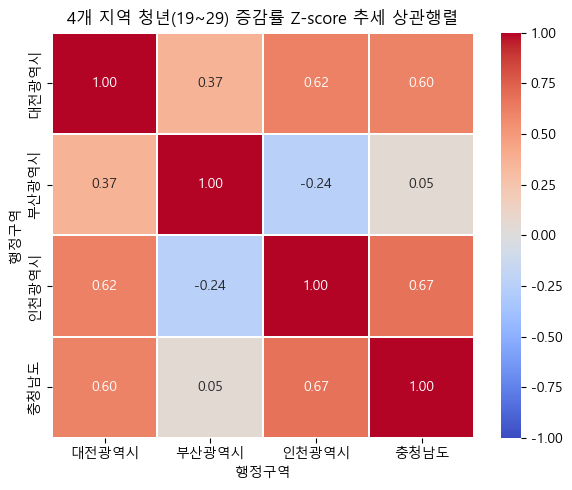

In [9]:
plt.figure(figsize=(6, 5))
sb.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.3)
plt.title('4개 지역 청년(19~29) 증감률 Z-score 추세 상관행렬')
plt.tight_layout()
plt.show()

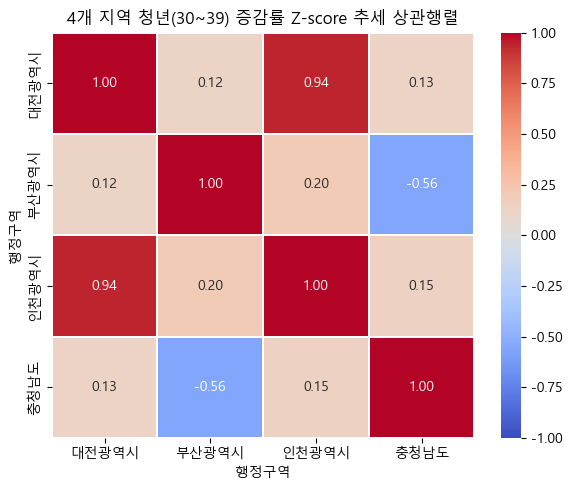

In [10]:
target_col = '청년_30_39_증감률(%)_z'

pivot_30 = (
    zscore_df[zscore_df['행정구역'].isin(regions)]
    .pivot(index='연도', columns='행정구역', values=target_col)
    .sort_index()
)

corr_matrix_30 = pivot_30.corr()

plt.figure(figsize=(6, 5))
sb.heatmap(corr_matrix_30, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.3)
plt.title('4개 지역 청년(30~39) 증감률 Z-score 추세 상관행렬')
plt.tight_layout()
plt.show()


In [4]:
bd = pd.read_excel('../../pre_note/nari/data/부산_대전_산업별_사업체수_종사자수_매출액_2020_2024.xlsx')
bd

,연도,행정구역,산업,사업체수(개),종사자수(명),매출액(백만원)
0,2020,부 산,제조업,38222,216869,54818045
1,2020,부 산,정보통신업,3857,20517,4772041
2,2020,부 산,"전문, 과학 및 기술 서비스업",12404,57503,8400335
3,2020,대 전,제조업,11049,67835,22977354
4,2020,대 전,정보통신업,2791,18869,4002605
5,2020,대 전,"전문, 과학 및 기술 서비스업",5765,55839,12837366
6,2021,부 산,제조업,38105,213028,62448313
7,2021,부 산,정보통신업,4111,21361,4742162
8,2021,부 산,"전문, 과학 및 기술 서비스업",12634,58661,8638618
9,2021,대 전,제조업,11047,67179,25339081
